# HE ANALYSIS

In this notebook we use the summary DFs that come from `process_HE_runs.py` (makes summary of the RECO hits per event) and `cut_HE_runs.py` (perform cuts on data).

A per-run spectra shift is performed, and dependencies with other variables are corrected to give a final energy resolution for the peaks.

# !!!!!!!!!!!!!!! ⚠️⚠️⚠️⚠️⚠️ ATTENTION: REDO THE RUN_CUT FILES BECAUSE I WRONGLY APPENDED ON THEM WITH THE FINAL ANALYSIS RESULTS

## Preparing data

In [1]:
import glob
import numpy as np
import pandas as pd
import tables as tb

import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib import cm

cmap = plt.get_cmap('viridis').copy()
cmap.set_under(color='white') 
plot_cmap = cm.get_cmap('turbo_r')

def lineal(x, a, b):
    return a*x + b

def in_range(x, rang):
    return (x > rang[0]) & (x < rang[1])

from scipy.optimize import curve_fit
from scipy.integrate import quad

def gauss(x, a, mu, sigma):
    return a * np.exp(-((x - mu) / sigma) ** 2 / 2)

def expon(x, m, c):
    return m *np.exp(-x/c)

def peak_fit(x, a, mu, sigma, m, c):
    return gauss(x, a, mu, sigma) + expon(x, m, c)

def fit_and_plot_peaks_resolution(data, fun, nbins, plotrange, fitrange, initial_params, bounds, title, density = True, plot = False):
    y, x = np.histogram(data, nbins, range = plotrange, density = density)

    total_counts = len(data)
    bin_width = x[1] - x[0]

    if density:
        yerr = np.sqrt(y) / (bin_width * total_counts)
    else:
        yerr = np.sqrt(y)
    
    # Prevent zero errors
    yerr[yerr == 0] = np.min(yerr[yerr > 0]) if np.any(yerr > 0) else 1.0
    
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y, fit_yerr = x[fit_mask], y[fit_mask[:-1]], yerr[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, sigma=fit_yerr, bounds = bounds, maxfev = 2000, absolute_sigma = True)
    err = np.sqrt(np.diag(cov))
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]
    yfit = fun(fit_x, a, mu, sigma, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((err[2] / sigma) **2 + (err[1]/mu)**2)

    if plot:
        legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, err[1]) + '\n' + \
                        r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, err[2]) + '\n' + \
                        r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
        plt.hist(data, nbins, range = plotrange, histtype='step', density = density)
        plt.errorbar(0.5 * (x[:-1] + x[1:]), y, yerr=yerr, fmt = ' ', c='tab:blue', alpha = 0.5)
        plt.plot(fit_x, yfit, 'r-', label = legend_string)
        plt.legend(fontsize = 12)
        plt.xlabel('E (MeV)', size = 14)
        if density:
            plt.ylabel('Probability density (1 / MeV)', size = 14)
        else:
            plt.ylabel('Events', size = 14)
        plt.title(title)
        plt.grid()
        plt.show()
    return [params, err], [R, sR]

def fit_whole_peaks(df, var, model, range, nbins, initial_params = None, bounds = ([0, 0, 0, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf]), density = False, title = '', plot = False):
    data = df[in_range(df[var], range)][var]

    y, x = np.histogram(data, nbins)
    if initial_params is None:
        A0 = max(y) - min(y)
        mu0 = x[np.argmax(y)]

        half_max = np.max(y) / 2
        indices = np.where(y > half_max)[0]
        fwhm = x[indices[-1]] - x[indices[0]]

        sig0 = fwhm / (2 * np.sqrt(2 * np.log(2)))  # FWHM = 2.355 * sigma
        m0 = np.min(y)

        initial_params = [A0, mu0, sig0, m0, 1]

    par, res = fit_and_plot_peaks_resolution(data, 
                                            model,
                                            nbins, 
                                            range, 
                                            range, 
                                            initial_params, 
                                            bounds, 
                                            title, 
                                            density=density, 
                                            plot = plot)
    return par, res

In [ ]:
run_numbers = [15589, 15590, 15591, 15592, 15593, 15594, 15596, 15597] #, 15604, 15605, 15607]

run_folder = 'HE_runs'
run_summary_name = 'run_cut_{}.h5'
wf_selection_name = 'sel_wf_{}.h5'

nocut_summary = 'ldc*run_{}.h5'

path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/{run_folder}/{run_number}/'

In [15]:
run_name_fun = lambda x: "q7_" + str(x) if np.isin(x, [15604, 15605, 15607]) else  str(x)

In [16]:
nlines = len(run_numbers)

min_val, max_val = 0.08, 0.9  
plot_colors = [plot_cmap(min_val + (max_val - min_val) * i / (nlines - 1)) for i in range(nlines)]

In [5]:
def lineal(x, a, b):
    return a * x + b

def apply_dst_cuts(dst, s1_DT_cut = [0.32, 500]):
    # Had to decouple cuts 
    #1S1
    dst_S1 = dst[dst.nS1 == 1]
    nev_S1 = len(dst_S1.event.unique())
    #1S2
    dst_S2 = dst_S1[dst_S1.nS2 == 1]
    nev_S2 = len(dst_S2.event.unique())
    #DT > 0
    dst_DT = dst_S2[dst_S2.DT > 0].copy()
    nev_DT = len(dst_DT.event.unique())
    #alphas
    dst_DT['limS1e'] = lineal(dst_DT.DT, s1_DT_cut[0], s1_DT_cut[1])
    dst_al = dst_DT[dst_DT.S1e < dst_DT.limS1e]
    nev_al = len(dst_al.event.unique())
    return dst_DT, [nev_S1, nev_S2, nev_DT, nev_al]


### Check things before fiducial cuts

In [ ]:
nocut_files = glob.glob(path.format(run_folder = run_folder, run_number = 15589) + nocut_summary.format(15589))

dst_nofid, reco_nofid = pd.DataFrame([]), pd.DataFrame([])

for file in nocut_files:
    dst = pd.read_hdf(file, 'DST/Events')
    reco = pd.read_hdf(file, 'RECO/Events_summary')
    # cut dst (1S1, 1S2, DT, alphas)
    dst, nev_dst = apply_dst_cuts(dst)
    reco = reco[np.isin(reco.event, dst.event.unique())]
    # append
    dst_nofid = dst_nofid.append(dst)
    reco_nofid = reco_nofid.append(reco)


KeyboardInterrupt: 

In [ ]:
reco_nofid = reco_nofid.fillna({'Ec_drop_in': 0, 'Ec_drop_out':0})
reco_nofid['total_energy_d'] = reco_nofid['total_energy'] - reco_nofid['Ec_drop_out']

In [109]:
pp_events_nofid = reco_nofid[in_range(reco_nofid.total_energy_d, (2.65, 2.85))]

In [136]:
cmap = plt.cm.jet
cmap.set_under('white')

/scratch/759633/ipykernel_3320328/1496793983.py:2: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("jet").copy()
  cmap.set_under('white')


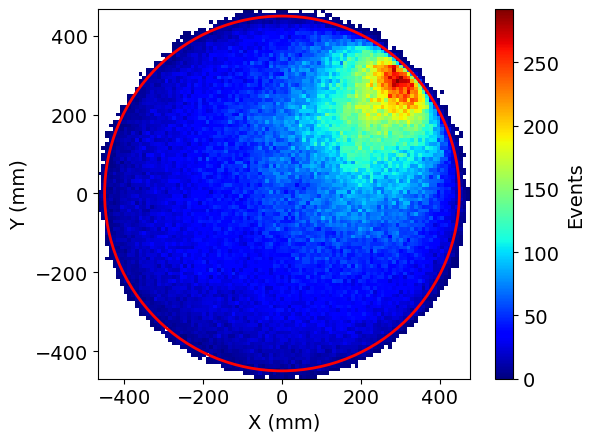

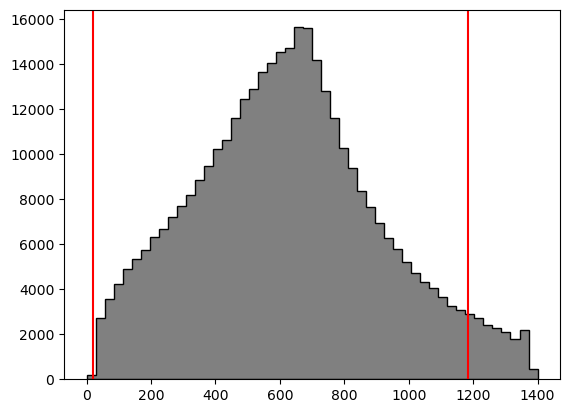

In [137]:
fig, ax = plt.subplots()
h = ax.hist2d(reco_nofid.X_bary, reco_nofid.Y_bary, (100, 100), cmap = cmap, vmin = 1e-10)
circle = plt.Circle((0, 0), 450, fill=False, linewidth=2, color = 'r')
ax.add_patch(circle)
ax.set_aspect('equal', adjustable='box')
cbar = fig.colorbar(h[3], ax=ax)
cbar.set_label("Events", size = 14)
cbar.ax.tick_params(labelsize = 14)
plt.xlabel('X (mm)', size = 14)
plt.ylabel('Y (mm)', size = 14)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.show()

plt.hist(reco_nofid.Z_bary, 50, (0, 1400), histtype='stepfilled', color = 'grey', edgecolor = 'k')
plt.axvline(20, color = 'r')
plt.axvline(1184, color = 'r')

In [126]:
h[3]

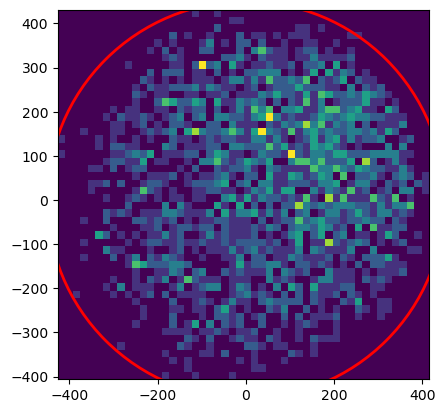

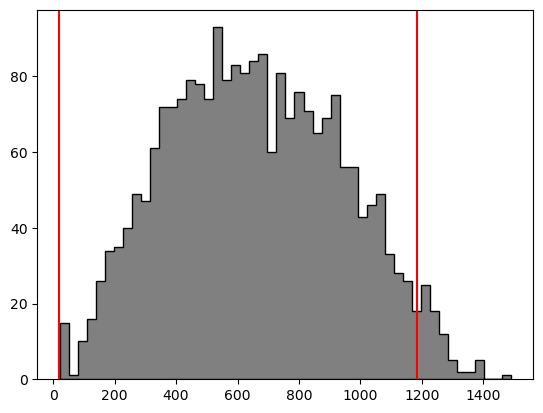

In [111]:
fig, ax = plt.subplots()
ax.hist2d(pp_events_nofid.X_bary, pp_events_nofid.Y_bary, (50, 50))
circle = plt.Circle((0, 0), 450, fill=False, linewidth=2, color = 'r')
ax.add_patch(circle)
ax.set_aspect('equal', adjustable='box')
plt.show()
plt.hist(pp_events_nofid.Z_bary, 50, histtype='stepfilled', color = 'grey', edgecolor = 'k')
plt.axvline(20, color = 'r')
plt.axvline(1184, color = 'r')

Join all run DST, RECO and efficiency information:

In [17]:
dst_summ, reco_summ, eff_summ = pd.DataFrame([]), pd.DataFrame([]), pd.DataFrame([])
for run_n in run_numbers:
    save_path_summary = path.format(run_folder = run_folder, run_number = run_n) + run_summary_name.format(run_name_fun(run_n)) # meter aqui el nuevo nombre con q7 para los runes especiales
    run_dst  = pd.read_hdf(save_path_summary, 'DST/Events')
    run_dst['run_n'] = str(run_n)
    run_reco = pd.read_hdf(save_path_summary, 'RECO/Events_summary')
    eff = pd.read_hdf(save_path_summary, 'RUN/eff')
    eff['run_n'] = run_n

    dst_summ = dst_summ.append(run_dst)
    reco_summ = reco_summ.append(run_reco)
    eff_summ = eff_summ.append(eff)


Fill with 0 some NaNs from those variables (forgot to do it in the script) and then correct the energy by the outer dropped hits energy.

In [18]:
reco_summ = reco_summ.fillna({'Ec_drop_in': 0, 'Ec_drop_out':0})
reco_summ['total_energy_d'] = reco_summ['total_energy'] - reco_summ['Ec_drop_out'] # - reco_summ['Ec_drop_in']

## Efficiences

Check the efficiency of the cuts of each run

(array([10., 20., 30., 40., 50., 60., 70., 80.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

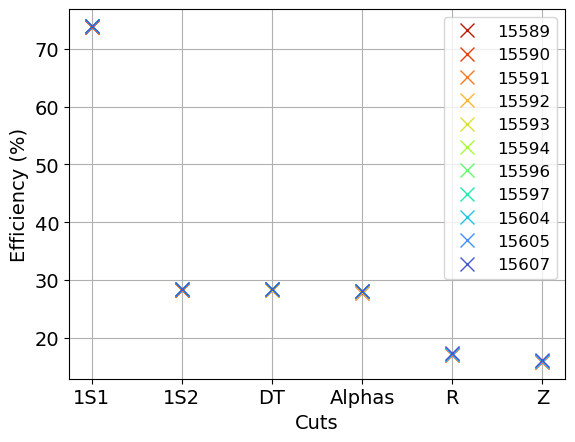

In [19]:
for run_n, c in zip(run_numbers, plot_colors):
    plt.plot(['1S1', '1S2', 'DT', 'Alphas', 'R', 'Z'], (eff_summ[eff_summ.run_n == run_n][['1S1', '1S2', 'DT', 'alphas', 'rad', 'z']] / eff_summ[eff_summ.run_n == run_n][['total']].values).T * 100, 'x', color = c, markersize = 10, label = run_n)
plt.grid()
plt.legend(fontsize = 12)
plt.xlabel('Cuts', size=14)
plt.ylabel('Efficiency (%)',size=14)
plt.xticks(size = 14)
plt.yticks(size=14)
# plt.savefig('/home/usc/ie/mpm/HE_plots/cut_eff.pdf', dpi=600, bbox_inches='tight', transparent = True) 

## Energy spectra

Plot the energy spectra (and the corrected spectra, which is marked with a `_d` for "dropped hits")

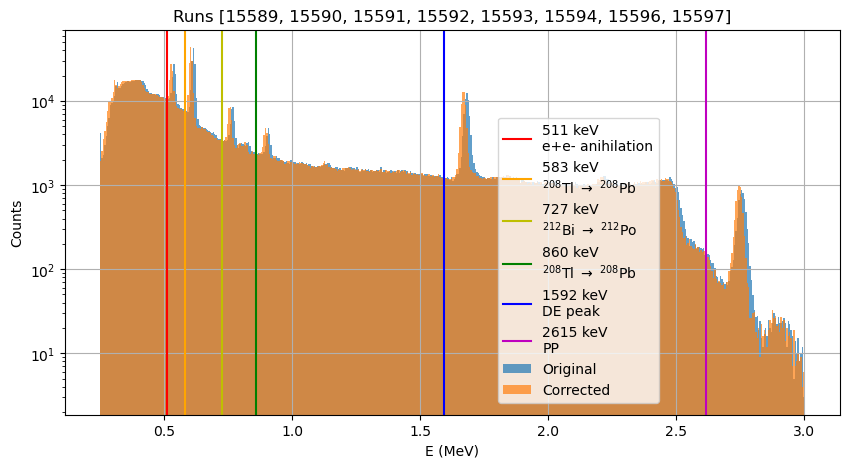

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.total_energy, 500, (0.25, 3), alpha = 0.7, label = 'Original')
plt.hist(reco_summ.total_energy_d, 500, (0.25, 3), alpha = 0.7, label = 'Corrected')


plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDE peak')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.grid()
plt.yscale('log')
plt.title('Runs {}'.format(run_numbers))
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.legend(loc = 'upper left', bbox_to_anchor = (0.55, 0.79))

Text(0, 0.5, 'Counts')

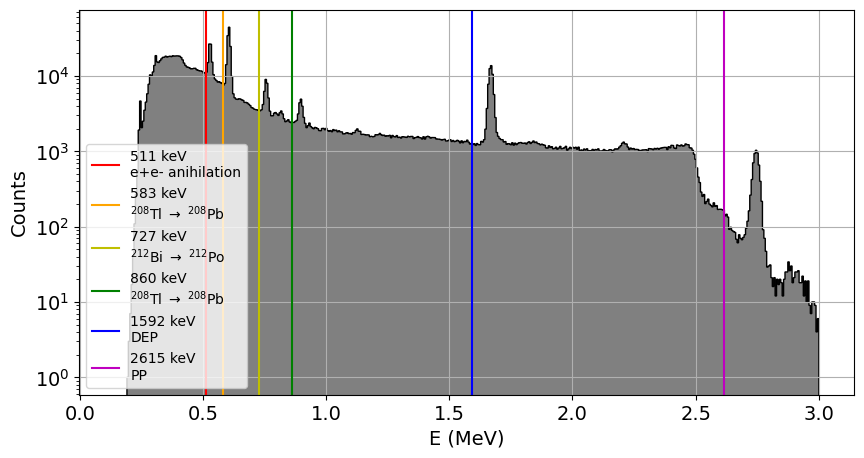

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.total_energy_d, 500, (0.14, 3), histtype='stepfilled', color = 'grey', edgecolor = 'k')

plt.grid()
plt.yscale('log')
plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDEP')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.legend(loc = 'lower left')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlabel('E (MeV)', size = 14)
plt.ylabel('Counts', size = 14)

# plt.savefig('/home/usc/ie/mpm/HE_plots/energy_spectra_noshift.pdf', dpi=600, bbox_inches='tight', transparent = True) 


## Energy scale

To get a good resolution of the peaks when joining several runs, we should fix the energy scale run by run.

In this section, we get the peak centers (`get_peak_centers`) run by run. Then, we fit the Real vs Measured peak energy to a line with slope m and interceipt b (`energy_scale_fit`), and shift the whole spectra by it, using:

$$E_{shift} = E * m + b $$ 

In [20]:
def get_peak_centers(run_numbers, reco_summ, variable, peak_ranges, npeaks = 4, plot = True):
    peak_nbins = [100, 100, 60, 40, 100, 25]
    peak_names  = ['e+e- anihilation (511 keV)', r'$^{208}$Tl $\rightarrow$ $^{208}$Pb (583 keV)', r'$^{212}$Bi $\rightarrow$ $^{212}$Po (727 keV)', r'$^{208}$Tl $\rightarrow$ $^{208}$Pb (860 keV)', '1592 keV\nDEP', '2615 keV\nPP']

    ranges = peak_ranges[:npeaks]
    nbins  = peak_nbins[:npeaks]
    names  = peak_names[:npeaks]
    
    meas_peaks = {}
    for run_n in run_numbers:
        run_reco = reco_summ[reco_summ.run_n == str(run_n)]
        meas_val, meas_err = [], []
        for rang, nbin, name in zip(ranges, nbins, names):
            par, res = fit_whole_peaks(run_reco, variable, peak_fit, rang, nbin, title = 'Run {} - '.format(run_n) + name, plot = plot)
            meas_val.append(par[0][1])
            meas_err.append(par[1][1])
        meas_peaks[run_n] = [meas_val, meas_err]
    return meas_peaks

def energy_scale_fit(meas_peaks, run_numbers, plot_colors, npeaks = 4):
    real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
    color_peak = ['r', 'orange', 'y', 'g', 'b', 'm']
    real_peaks = real_peaks[:npeaks]
    color_peak = color_peak[:npeaks]
    
    parameters = {}
    for run_n, c in zip(run_numbers, plot_colors):
        if run_n not in meas_peaks.keys(): continue
        if len(meas_peaks[run_n][0]) == 0: continue
        for m_, e_, r_, c_ in zip(meas_peaks[run_n][0], meas_peaks[run_n][1], real_peaks, color_peak):
            # plt.plot(m_, r_, '.', color = c_)
            plt.errorbar(m_, r_, yerr = e_, color=c_, marker='.', capsize=2)
        par, err  = curve_fit(lineal, meas_peaks[run_n][0], real_peaks, p0 = (1, 0))
        plt.plot(meas_peaks[run_n][0], lineal(np.array(meas_peaks[run_n][0]), *par), color = c, label = str(run_n) + '\n m = {:.2e}'.format(par[0]) + '\n n = {:.2e}'.format(par[1]))
        parameters[run_n] = par
    plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), fontsize =12)
    plt.grid()
    plt.xlabel('Measured peak energy (MeV)', size = 14)
    plt.ylabel('Real peak energy (MeV)', size = 14)
    plt.xticks(size = 14)
    plt.yticks(size = 14)
    return parameters


def plot_real_vs_meas_peaks(meas_peaks, run_numbers, plot_colors, npeak = 4):
    real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
    real_peaks = real_peaks[:npeak]
    for run_n, c in zip(run_numbers, plot_colors):
        if run_n not in meas_peaks.keys(): continue
        if len(meas_peaks[run_n][0]) == 0: continue
        m_ = np.array(meas_peaks[run_n][0])
        e_ = np.array(meas_peaks[run_n][1])
        r_ = np.array(real_peaks)
        plt.errorbar(r_, ((m_ - r_) / r_) * 100, yerr = e_ * 100, color = c, markersize = 10, label = run_n, marker = '.', capsize=2)
    plt.legend(fontsize = 12)
    plt.grid()
    plt.xlabel('Real peak energy (MeV)', size = 14)
    plt.ylabel('(Measured - Real) / Real peak energy (%)', size = 14)
    plt.xticks(size = 14)
    plt.yticks(size = 14)

In [21]:
real_peaks = [0.511, 0.583, 0.727, 0.86, 1.592, 2.615]
peak_ranges = [(0.5, 0.58), (0.58, 0.65), (0.72, 0.81), (0.85, 0.95), (1.62, 1.75), (2.7, 2.8)]
peak_ranges_d = [(0.48, 0.56), (0.57, 0.64), (0.71, 0.80), (0.85, 0.95), (1.59, 1.72), (2.69, 2.79)]

Obtaining the measured peaks (for both the regular spectra and the corrected by the outer dropped hits energy), and from them the shifting parameters

In [22]:
meas_peaks = get_peak_centers(run_numbers, reco_summ, 'total_energy', peak_ranges, npeaks=6, plot = False)
meas_peaks_d = get_peak_centers(run_numbers, reco_summ, 'total_energy_d', peak_ranges_d, npeaks = 6, plot = False)

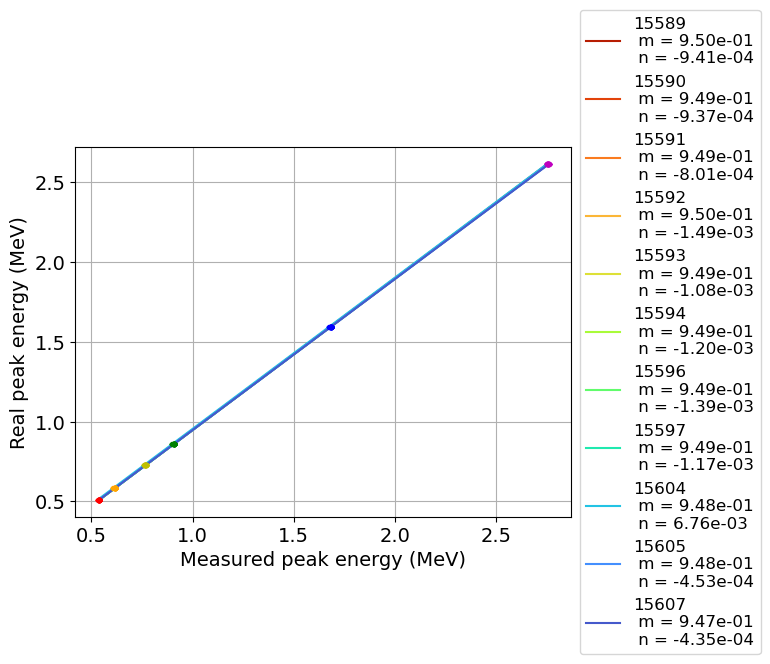

In [23]:
param = energy_scale_fit(meas_peaks, run_numbers, plot_colors, npeaks = 6)

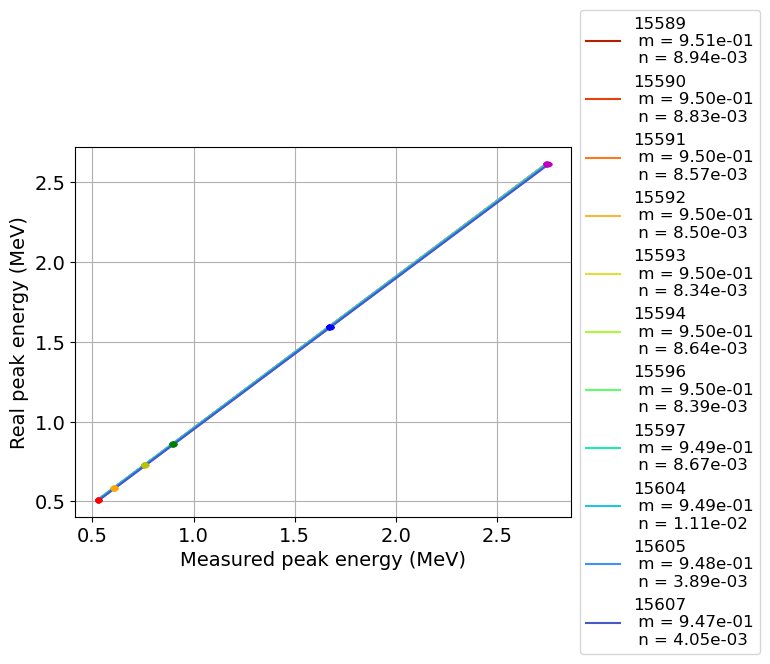

In [24]:
param_d = energy_scale_fit(meas_peaks_d, run_numbers, plot_colors, npeaks = 6)
# plt.savefig('/home/usc/ie/mpm/HE_plots/lin_calib.pdf', dpi=600, bbox_inches='tight', transparent = True) 

We can plot how much each peak differ from the real value

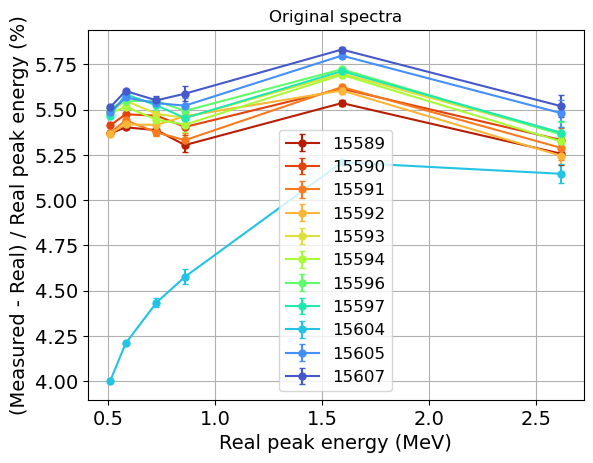

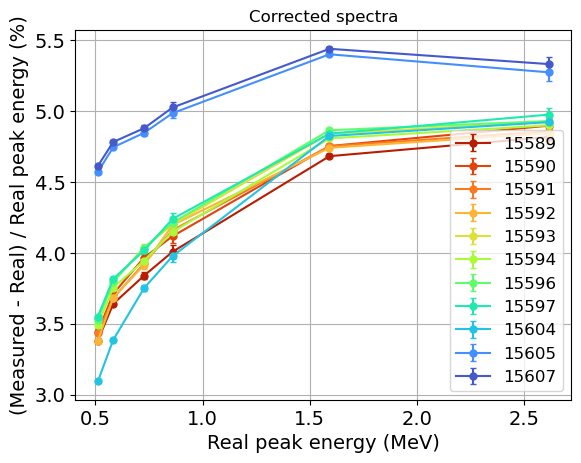

In [25]:
plot_real_vs_meas_peaks(meas_peaks, run_numbers, plot_colors, npeak = 6)
plt.title('Original spectra')
plt.show()
plot_real_vs_meas_peaks(meas_peaks_d, run_numbers, plot_colors, npeak = 6)
plt.title('Corrected spectra')
plt.show()

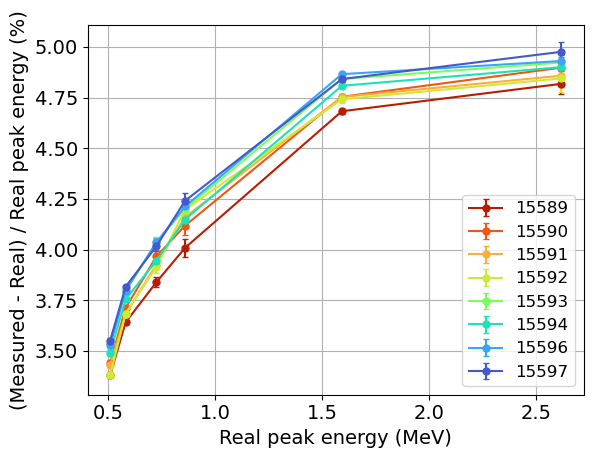

In [17]:
plot_real_vs_meas_peaks(meas_peaks_d, run_numbers, plot_colors, npeak = 6)
# plt.savefig('/home/usc/ie/mpm/HE_plots/perc_shift.pdf', dpi=600, bbox_inches='tight', transparent = True) 


Doing the correction using the obtained parameters

In [12]:
reco_summ['E_shifted']   = reco_summ['total_energy'] * reco_summ['run_n'].map(lambda r: param[int(r)][0]) + reco_summ['run_n'].map(lambda r: param[int(r)][1])
reco_summ['E_shifted_d'] = reco_summ['total_energy_d'] * reco_summ['run_n'].map(lambda r: param_d[int(r)][0]) + reco_summ['run_n'].map(lambda r: param_d[int(r)][1])

Plotting the shifted spectras

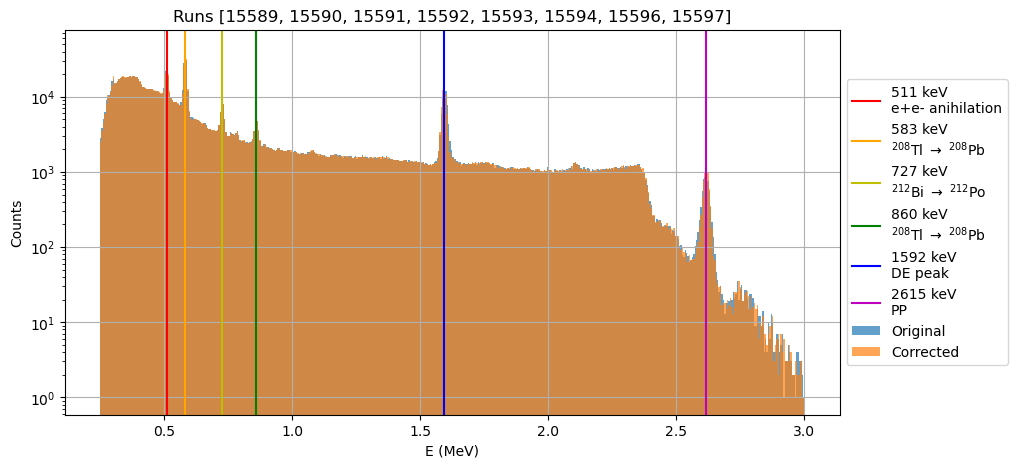

In [19]:
plt.figure(figsize=(10, 5))
# plt.hist(reco_summ.total_energy, 500, (0.25, 3), alpha = 0.7, label = 'Original')
plt.hist(reco_summ.E_shifted, 500, (0.25, 3), alpha = 0.7, label = 'Original')
plt.hist(reco_summ.E_shifted_d, 500, (0.25, 3), alpha = 0.7, label = 'Corrected')

plt.grid()
plt.yscale('log')
plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDE peak')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.title('Runs {}'.format(run_numbers))
plt.xlabel('E (MeV)')
plt.ylabel('Counts')
plt.legend(loc = 'center left', bbox_to_anchor = (1, 0.5))

Text(0, 0.5, 'Counts')

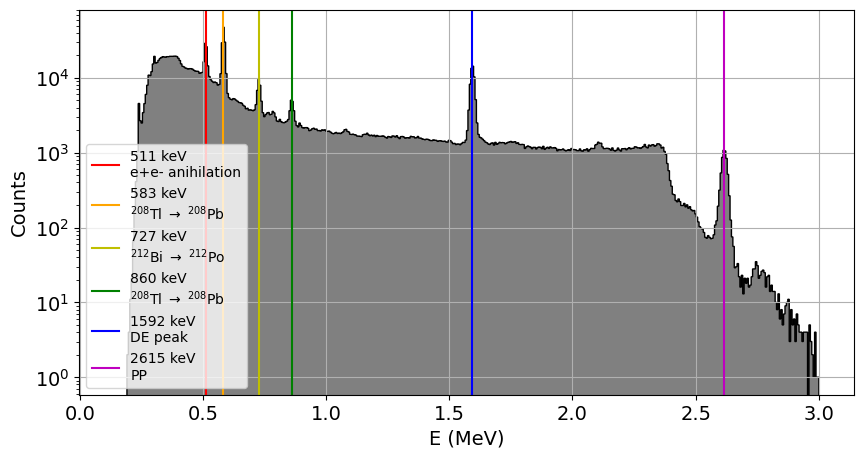

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(reco_summ.E_shifted_d, 500, (0.14, 3), histtype='stepfilled', color = 'grey', edgecolor = 'k')

plt.grid()
plt.yscale('log')
plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDE peak')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.legend(loc = 'lower left')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlabel('E (MeV)', size = 14)
plt.ylabel('Counts', size = 14)

# plt.savefig('/home/usc/ie/mpm/HE_plots/energy_spectra.pdf', dpi=600, bbox_inches='tight', transparent = True) 


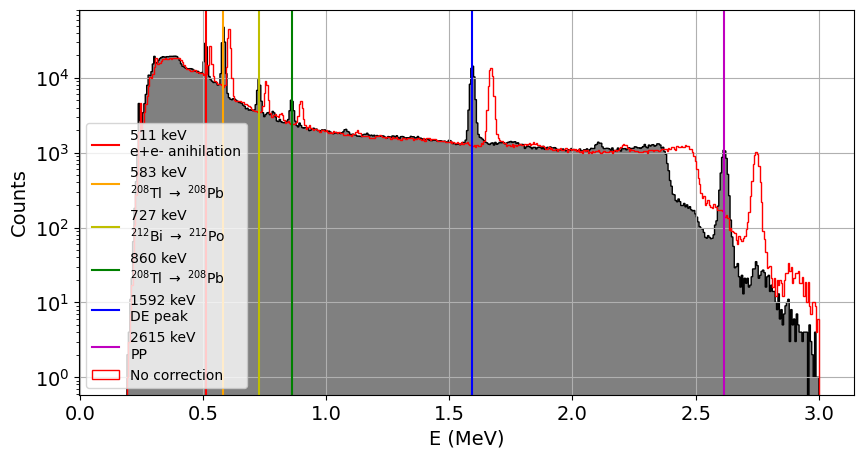

In [116]:
plt.figure(figsize=(10, 5))
# plt.hist(reco_summ.total_energy_d, 500, (0.14, 3), histtype='stepfilled', color = 'white', edgecolor = 'k', alpha = 1)
plt.hist(reco_summ.E_shifted_d, 500, (0.14, 3), histtype='stepfilled', color = 'grey', edgecolor = 'k', alpha = 1)
plt.hist(reco_summ.total_energy_d, 500, (0.14, 3), histtype='step', edgecolor = 'r', alpha = 1, label = 'No correction')


plt.grid()
plt.yscale('log')
plt.axvline(0.511, c = 'r', label = '511 keV\ne+e- anihilation')
plt.axvline(0.583, c = 'orange', label = '583 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(0.727, c = 'y', label = '727 keV\n' + r'$^{212}$Bi $\rightarrow$ $^{212}$Po')
plt.axvline(0.860, c = 'g', label = '860 keV\n' + r'$^{208}$Tl $\rightarrow$ $^{208}$Pb')
plt.axvline(1.592, c = 'b', label = '1592 keV\nDE peak')
plt.axvline(2.615, c = 'm', label = '2615 keV\nPP')
plt.legend(loc = 'lower left')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlabel('E (MeV)', size = 14)
plt.ylabel('Counts', size = 14)

plt.savefig('/home/usc/ie/mpm/HE_plots/ene_spec_comp.pdf', dpi=600, bbox_inches='tight', transparent = True) 

We can get again the peak centers, now for the shifted spectras, to check how much they still differ from the original values

In [13]:
peak_ranges_shift = [(0.48, 0.55), (0.55, 0.61), (0.7, 0.76), (0.83, 0.89), (1.52, 1.67), (2.55, 2.67)]

In [14]:
meas_peaks_shift = get_peak_centers(run_numbers, reco_summ, 'E_shifted', peak_ranges_shift, npeaks=6, plot = False)
meas_peaks_shift_d = get_peak_centers(run_numbers, reco_summ, 'E_shifted_d', peak_ranges_shift, npeaks=6, plot = False)

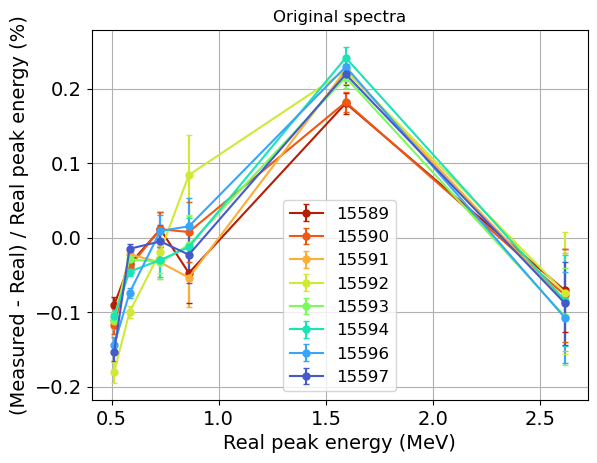

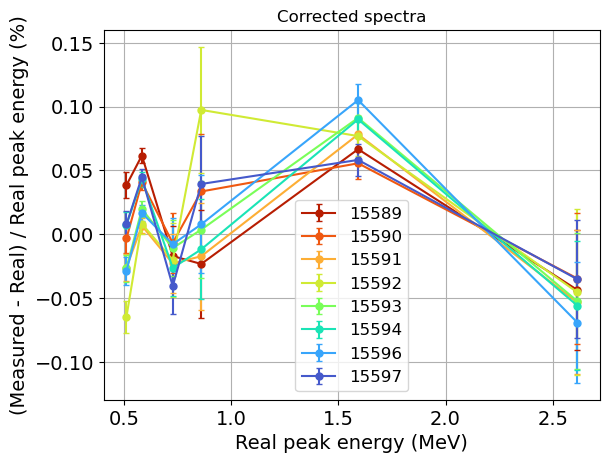

In [23]:
plot_real_vs_meas_peaks(meas_peaks_shift, run_numbers, plot_colors, npeak=6)
plt.title('Original spectra')
plt.show()
plot_real_vs_meas_peaks(meas_peaks_shift_d, run_numbers, plot_colors, npeak=6)
plt.title('Corrected spectra')
plt.show()

## Energy resolution

We can do a first estimation of the energy resolution now that the energy scale has been fixed run by run. In this case I'm doing it for the corrected spectra by the outer dropped energy hits.

I'm doing it for all peaks to check how each one of them extrapolates.

In [16]:
def extrapol_energy(R_0, E_0, s_R_0, s_E_0, E_1):
    R_1 = R_0 * np.sqrt(E_0 / E_1)
    s_R_1 = np.sqrt((E_0 / E_1) * s_R_0 **2 + (1/4) * R_0 **2 * (E_1 / E_0) * s_E_0 ** 2)
    return R_1, s_R_1

In [17]:
ene_var_corr = 'E_shifted_d'

fit_ranges = [(0.495, 0.527), (0.565, 0.603), (0.702, 0.752), (0.84, 0.88),  (1.57, 1.62), (2.58, 2.65)]
fit_nbins  = [100, 100, 100, 60, 120, 60]
fit_names  = ['511', '583', '727', '860', '1592', '2615']

In [17]:
peaks = []
resol = []
for rng, nbin, name in zip(fit_ranges, fit_nbins, fit_names):
    par, R = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, rng, nbin, title = 'Run {} - '.format(run_numbers) + name, plot = False)
    plt.show()
    peaks.append([par[0][1], par[1][1]])
    resol.append(R)
for R, name in zip(resol, fit_names):
    print('Energy resolution {}: {:.3f} ± {:.3f} %'.format(name, R[0], R[1]))

Energy resolution 511: 2.127 ± 0.025 %
Energy resolution 583: 2.084 ± 0.011 %
Energy resolution 727: 1.931 ± 0.031 %
Energy resolution 860: 1.695 ± 0.063 %
Energy resolution 1592: 1.170 ± 0.010 %
Energy resolution 2615: 0.965 ± 0.023 %


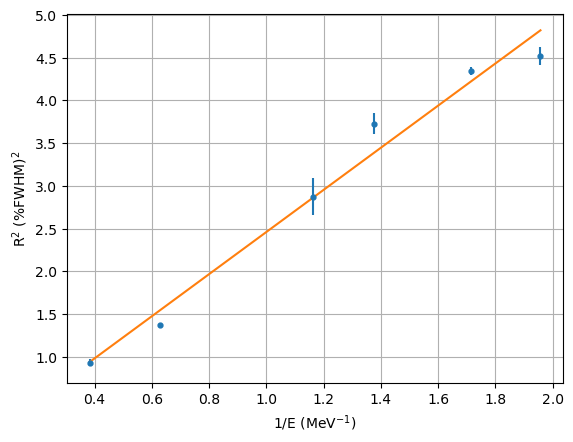

In [27]:
e_inv = 1 / (np.array(peaks)[:, 0])
r_sq = np.array(resol)[:, 0]**2
r_sq_s = 2 * np.array(resol)[:, 0] * np.array(resol)[:, 1]


plt.errorbar(e_inv, r_sq, yerr= r_sq_s, ls = 'none',  marker = '.', markersize = 7)

p, e = curve_fit(lineal, e_inv, r_sq, p0 = (1, 0))
plt.plot(e_inv, lineal(e_inv, *p))

plt.xlabel('1/E (MeV$^{-1}$)')
plt.ylabel('R$^2$ (%FWHM)$^2$')
plt.grid()

In [28]:
E_1 = 2.615 #2.4578
extrapol, extrapol_s = extrapol_energy(np.array(resol)[:, 0], np.array(peaks)[:, 0], np.array(resol)[:, 1], np.array(peaks)[:, 1], E_1)

In [29]:
for ext, ext_s, name in zip(extrapol, extrapol_s, fit_names):
    print('Extrapolated E res {} to {}: {:.3f} ± {:.3f} %'.format(name, E_1, ext, ext_s))

Extrapolated E res 511 to 2.615: 0.940 ± 0.011 %
Extrapolated E res 583 to 2.615: 0.984 ± 0.005 %
Extrapolated E res 727 to 2.615: 1.018 ± 0.017 %
Extrapolated E res 860 to 2.615: 0.972 ± 0.036 %
Extrapolated E res 1592 to 2.615: 0.913 ± 0.008 %
Extrapolated E res 2615 to 2.615: 0.966 ± 0.023 %


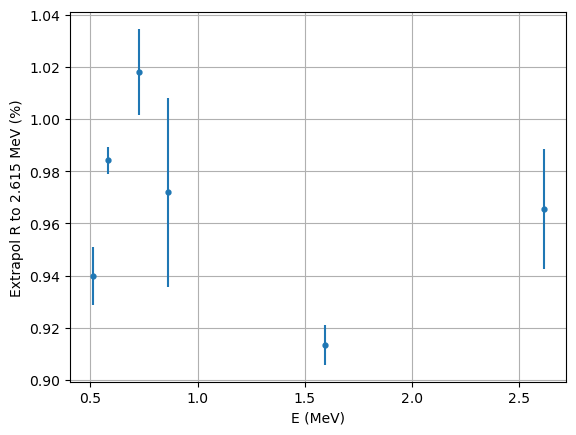

In [30]:
plt.errorbar(np.array(peaks)[:, 0], extrapol, yerr = extrapol_s, ls = 'none', marker = '.', markersize = 7)
plt.xlabel('E (MeV)')
plt.ylabel('Extrapol R to {} MeV (%)'.format(E_1))
plt.grid()

In [18]:
dep_range = fit_ranges[-2]
pp_range = fit_ranges[-1]

dep_nbins = fit_nbins[-2]
pp_nbins = fit_nbins[-1]

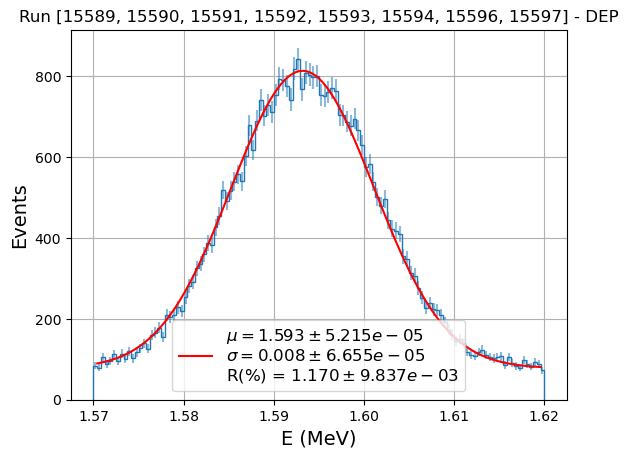

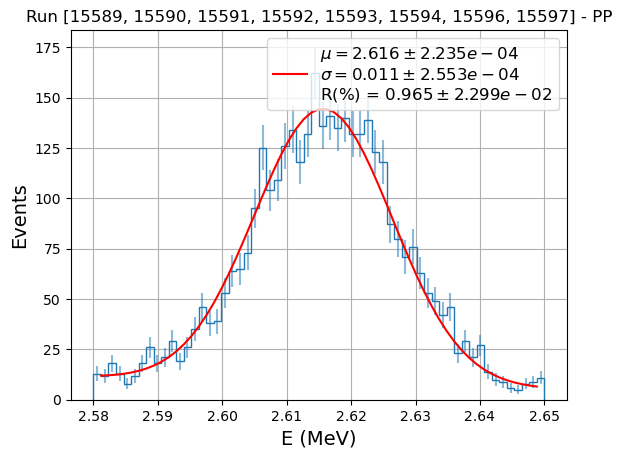

Energy resolution DEP: 1.170 ± 0.010 %
Energy resolution PP: 0.965 ± 0.023 %


In [32]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, dep_range, dep_nbins, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_pp  = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, pp_nbins, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))

In [19]:
# Tried to modify the functions to be more paper-like plots
def fit_and_plot_peaks_resolution_paper(data_fit, data_plot, fun, nbins, plotrange, fitrange, initial_params, bounds, title, density = True, plot = False):
    y, x = np.histogram(data_fit, nbins, range = plotrange, density = density)

    total_counts = len(data_fit)
    bin_width = x[1] - x[0]

    if density:
        yerr = np.sqrt(y) / (bin_width * total_counts)
    else:
        yerr = np.sqrt(y)
    
    # Prevent zero errors
    yerr[yerr == 0] = np.min(yerr[yerr > 0]) if np.any(yerr > 0) else 1.0
    
    # from the xbins we select the range to plot, otherwise things don't match
    fit_mask = (x > fitrange[0]) & (x < fitrange[1])
    fit_x, fit_y, fit_yerr = x[fit_mask], y[fit_mask[:-1]], yerr[fit_mask[:-1]]
    params, cov = curve_fit(fun, fit_x, fit_y, p0=initial_params, sigma=fit_yerr, bounds = bounds, maxfev = 2000, absolute_sigma = True)
    err = np.sqrt(np.diag(cov))
    a, mu, sigma, m, c = params[0], params[1], params[2], params[3], params[4]
    yfit = fun(fit_x, a, mu, sigma, m, c)

    R = 2 * np.sqrt(2 * np.log(2)) * sigma * 100 / mu
    sR = R * np.sqrt((err[2] / sigma) **2 + (err[1]/mu)**2)

    if plot:
        legend_string = r'$\mu={:.3f} \pm {:.3e}$'.format(mu, err[1]) + '\n' + \
                        r'$\sigma={:.3f} \pm {:.3e}$'.format(sigma, err[2]) + '\n' + \
                        r'R(%) = ${:.3f} \pm {:.3e}$'.format(R, sR)
        plt.hist(data_plot, nbins, range = plotrange, histtype='stepfilled', edgecolor = 'k', color = 'grey', density = density)
        plt.errorbar(0.5 * (x[:-1] + x[1:]), y, yerr=yerr, fmt = ' ', c='darkgrey', alpha = 0.5, elinewidth=0.8)
        plt.plot(fit_x, yfit, 'r-', label = legend_string)
        plt.legend(fontsize = 12)
        plt.xlabel('E (MeV)', size = 14)
        if density:
            plt.ylabel('Probability density (1 / MeV)', size = 14)
        else:
            plt.ylabel('Events', size = 14)
        plt.xticks(size = 14)
        plt.yticks(size = 14)
        plt.title(title)
        plt.grid()
        # plt.show()
    return [params, err], [R, sR]

def fit_whole_peaks_paper(df, var, model, plotrange, fitrange, nbins, initial_params = None, bounds = ([0, 0, 0, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf]), density = False, title = '', plot = False):
    data_fit  = df[in_range(df[var], fitrange)][var]
    data_plot = df[in_range(df[var], plotrange)][var]

    y, x = np.histogram(data_fit, nbins)
    if initial_params is None:
        A0 = max(y) - min(y)
        mu0 = x[np.argmax(y)]

        half_max = np.max(y) / 2
        indices = np.where(y > half_max)[0]
        fwhm = x[indices[-1]] - x[indices[0]]

        sig0 = fwhm / (2 * np.sqrt(2 * np.log(2)))  # FWHM = 2.355 * sigma
        m0 = np.min(y)

        initial_params = [A0, mu0, sig0, m0, 1]

    par, res = fit_and_plot_peaks_resolution_paper(data_fit,
                                             data_plot, 
                                            model,
                                            nbins, 
                                            plotrange, 
                                            fitrange, 
                                            initial_params, 
                                            bounds, 
                                            title, 
                                            density=density, 
                                            plot = plot)
    return par, res

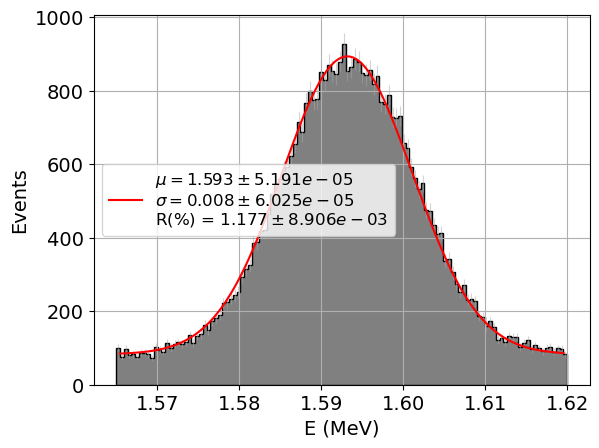

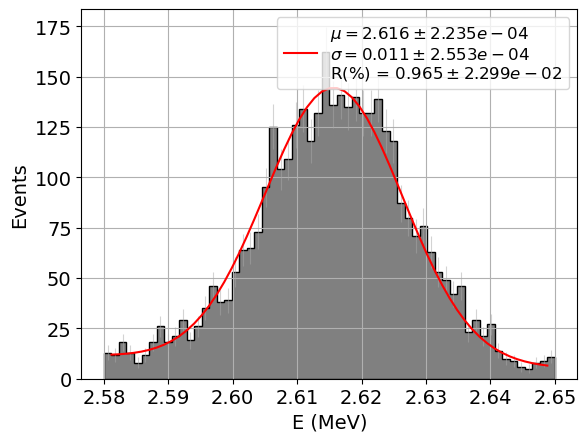

In [34]:
_, r_dep = fit_whole_peaks_paper(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, (1.565, 1.62), (1.565, 1.62), dep_nbins, plot = True)
# plt.savefig('/home/usc/ie/mpm/HE_plots/dep.pdf', dpi=600, bbox_inches='tight', transparent = True) 
plt.show()
_, r_pp  = fit_whole_peaks_paper(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, pp_range, pp_nbins, plot = True)
# plt.savefig('/home/usc/ie/mpm/HE_plots/pp.pdf', dpi=600, bbox_inches='tight', transparent = True) 


## Energy dependencies

In [103]:
from invisible_cities.core.fit_functions import expo
from invisible_cities.core.fit_functions import profileX
from scipy.optimize                      import curve_fit

def quad(x, a, b, c):
    return a*x**2 + b*x + c

def fit_profile(df, xvar, yvar, fitfun, initial_values=None, fitbins=20, fitrange=(None, None), band_width=None):
    """
    Two-step fitting:
      1. Fit all data binned (used only to define band).
      2. If band_width is given, select points within band around first fit
         and redo the fit. This second fit is the final result.
    Returns final fit parameters, errors, and (x, y, sy).
    """
    # First binning
    x, y, sy = profileX(df[xvar], df[yvar], std=True, nbins=fitbins, xrange=fitrange[0], yrange=fitrange[1])

    # First fit (estimator)
    par_est, _ = curve_fit(fitfun, x, y, sigma=sy, p0=initial_values)

    if band_width is not None:
        # Compute band from first fit
        y_pred = fitfun(df[xvar], *par_est)
        mask = (df[yvar] >= y_pred - band_width) & (df[yvar] <= y_pred + band_width)
        df_band = df[mask]

        # Redo profile with band-limited data
        x, y, sy = profileX(df_band[xvar], df_band[yvar], std=True, nbins=fitbins, xrange=fitrange[0], yrange=fitrange[1])

        # Final fit (this one is returned)
        par, cov = curve_fit(fitfun, x, y, sigma=sy, p0=par_est)
    else:
        # If no band is defined, just return the first fit
        par, cov = curve_fit(fitfun, x, y, sigma=sy, p0=initial_values)

    err = np.sqrt(np.diag(cov))
    return par, err, (x, y, sy)


def plot_profile(df, xvar, yvar, fitfun=None, initial_values=None, std=False, 
                 fitbins=20, plotbins=(50, 50), fitrange=(None, None), plotrange=(None, None), 
                 axlabel=['', ''], units=['mm', 'MeV'], title='', cmap='viridis', 
                 save=False, band_width=None):
    """
    Plot histogram, profile, and final fit results.
    """

    par, err, (x, y, sy) = (None, None, (None, None, None))
    if fitfun:
        par, err, (x, y, sy) = fit_profile(
            df, xvar, yvar, fitfun, 
            initial_values=initial_values, 
            fitbins=fitbins, fitrange=fitrange, 
            band_width=band_width
        )

        # Labels for parameters
        # label_lines = [
        #     f'$x_{{{i}}}$ = {p:.2e} ' + r'$\mathrm{' + units[1] + r'}/\mathrm{' + units[0] + r'}^{{' + f'{i}' + '}}$' 
        #     for i, p in enumerate(par[::-1])
        # ]
        label_lines = [f'$x_{0}$ = {par[1]:.2e} ' + units[1], f'$x_{1}$ = {par[0]:.2e} ' + units[1]  + '/' + units[0] ]

        label = "\n".join(label_lines)
        
        # Final fit curve
        x_fit = np.linspace(df[xvar].min(), df[xvar].max(), 500)
        plt.plot(x_fit, fitfun(x_fit, *par), 'r-', label=label)

        # Draw band lines around final fit
        if band_width:
            y_fit = fitfun(x_fit, *par)
            plt.plot(x_fit, y_fit + band_width, 'r--', alpha=0.7)
            plt.plot(x_fit, y_fit - band_width, 'r--', alpha=0.7)

    # Profile with error bars
    if x is not None:
        plt.errorbar(x, y, yerr=sy, fmt='r.')

    # 2D histogram (all data shown)
    plt.hist2d(df[xvar], df[yvar], bins=plotbins, range=plotrange, cmap=cmap, vmin=1e-3)

    # Formatting
    plt.xlabel(axlabel[0] + f' ({units[0]})', size=14)
    plt.ylabel(axlabel[1] + f' ({units[1]})', size=14)
    plt.xticks(size=14)
    plt.yticks(size=14)
    plt.legend(loc='upper left', fontsize=14)
    plt.title(title)

    if not save:
        plt.show()

    return par, err
    
def plot_hist2d(df, xvar, yvar, plotbins = (50, 50), plotrange = (None, None), axlabel = ['', ''], units = ['mm', 'MeV'], title = '', cmap = 'viridis'):
    plt.hist2d(df[xvar], df[yvar], bins = plotbins, range = plotrange, cmap = cmap, vmin = 1e-3)
    plt.xlabel(axlabel[0] + ' ({})'.format(units[0]), size = 14)
    plt.ylabel(axlabel[1] + ' ({})'.format(units[1]), size = 14)
    plt.title(title)
    plt.xticks(size = 14)
    plt.yticks(size = 14)
    plt.show()

Lets look mainly to the dependencies in Z, and how they change with energy

In [36]:
# for rng, name, dzrng in zip(fit_ranges[-2:], fit_names[-2:], dz_range):
#     df = reco_summ[in_range(reco_summ[ene_var_corr], rng)]
#     plot_profile(df, 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 20), fitrange=(dzrng, None), plotrange=(dzrng, None), axlabel = ['dZ', 'E'], title='Runs {} - {}'.format(run_numbers, name), cmap=cmap)
#     plot_profile(df, 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=20, plotbins=(20, 20), fitrange=((200, 1000), None), plotrange=((200, 1000), None), axlabel = ['Z_bary', 'E'], title='Runs {} - {}'.format(run_numbers, name), cmap=cmap)
#     dzbins = np.linspace(dzrng[0], dzrng[1], 5)
#     print('***************************************')
#     for i, val in enumerate(dzbins[:-1]):
#         plot_profile(df[in_range(df['dZ'], (dzbins[i], dzbins[i+1]))], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=20, plotbins=(20, 20), fitrange=((200, 1000), None), plotrange=((200, 1000), None), axlabel = ['Z_bary', 'E'], title='Runs {} - {} - {}'.format(run_numbers, name, (dzbins[i], dzbins[i+1])), cmap=cmap)
#         plt.show()
#     print('***************************************')


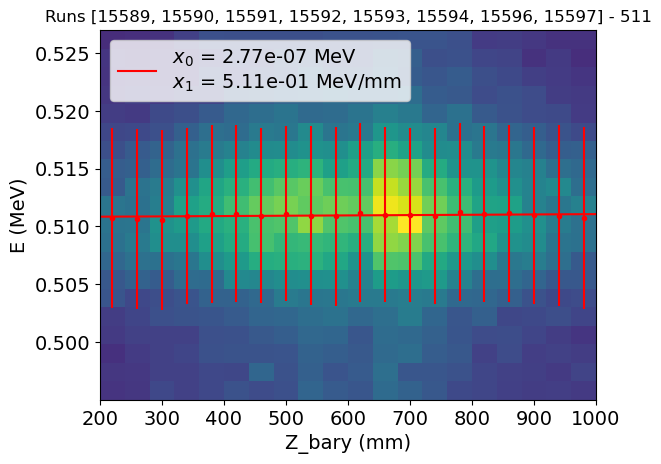

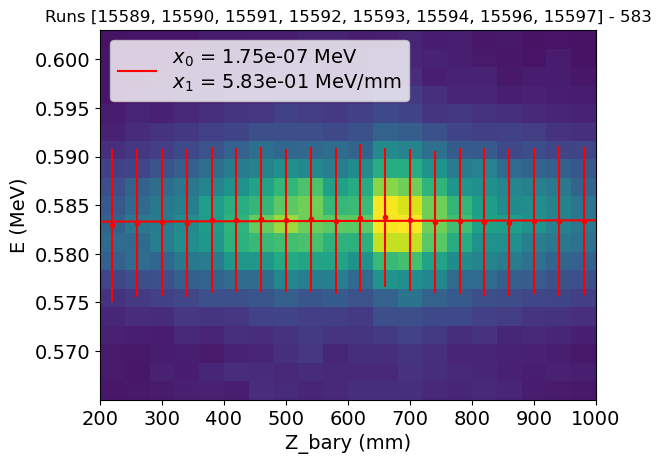

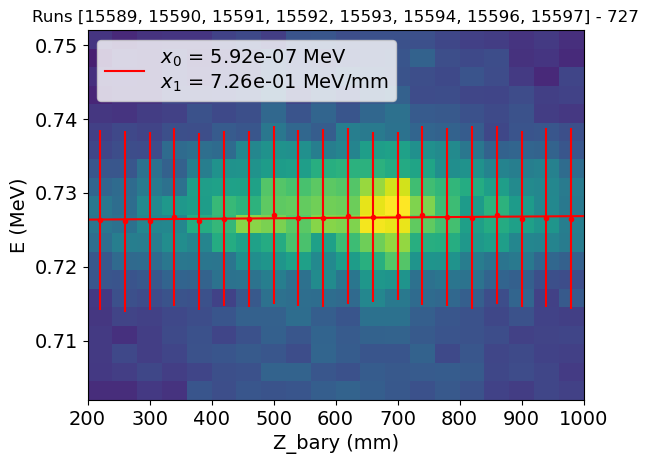

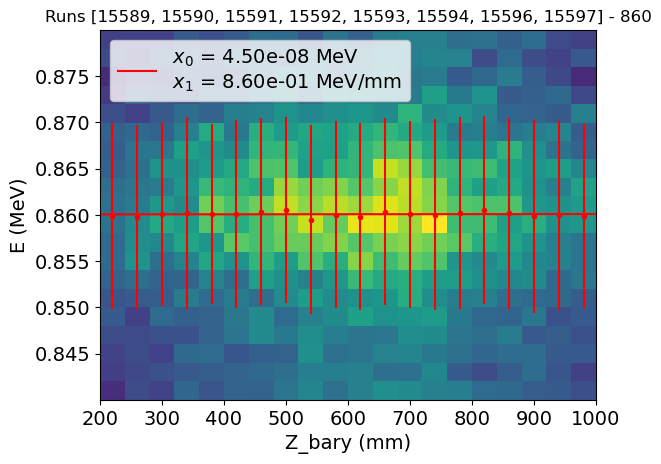

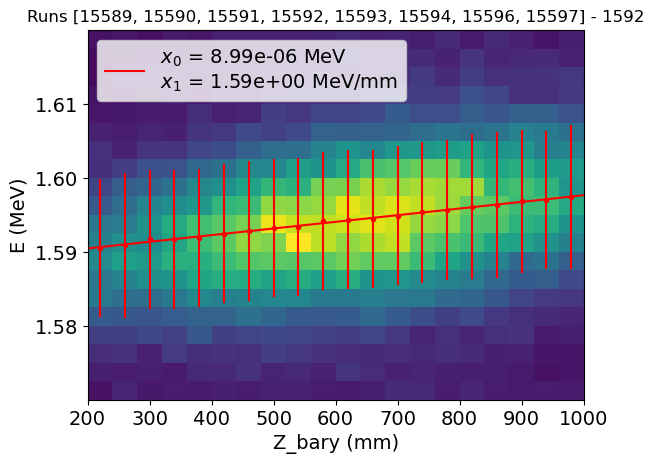

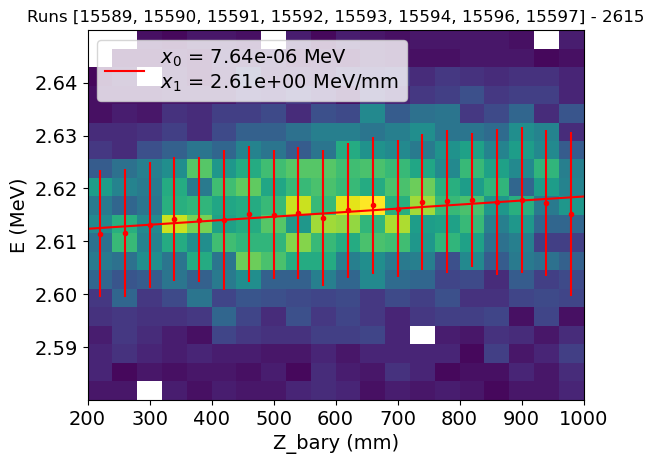

In [90]:
Zcorr, Zcorr_err = [], []
for rng, name in zip(fit_ranges, fit_names):
    par_Z, err_Z = plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], rng)], 'Z_bary', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=20, plotbins=(20, 20), fitrange=((200, 1000), None), plotrange=((200, 1000), None), axlabel = ['Z_bary', 'E'], title='Runs {} - {}'.format(run_numbers, name), cmap=cmap)
    plt.show()
    Zcorr.append(par_Z)
    Zcorr_err.append(err_Z)

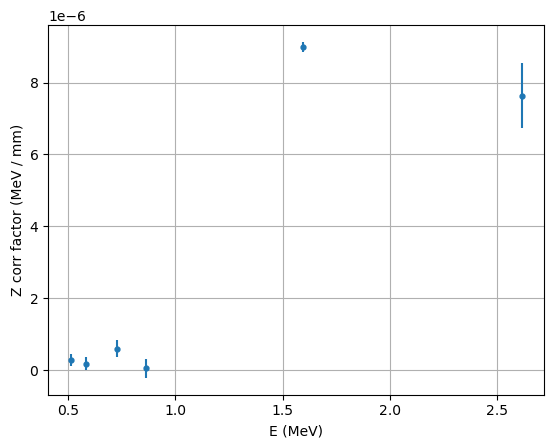

In [39]:
plt.errorbar(np.array(peaks)[:, 0], np.array(Zcorr)[:, 0], yerr = np.array(Zcorr_err)[:, 0], ls = 'none', marker = '.', markersize = 7)
plt.xlabel('E (MeV)')
plt.ylabel('Z corr factor (MeV / mm)')
plt.grid()

In [21]:
reco_summ = reco_summ.merge(dst_summ[['event', 'run_n', 'S1e', 'S2e']], on = ['event', 'run_n'])

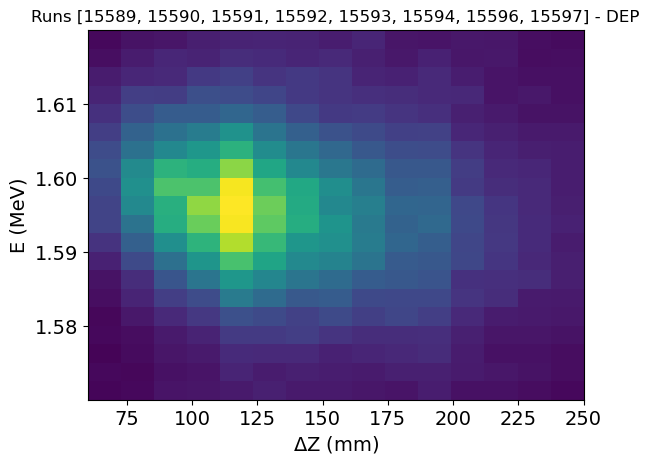

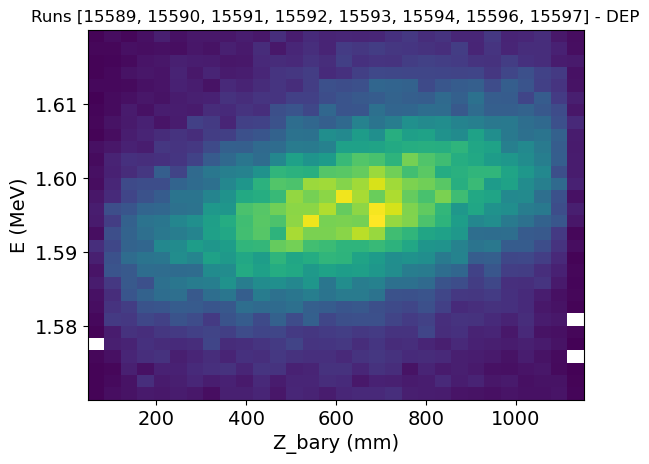

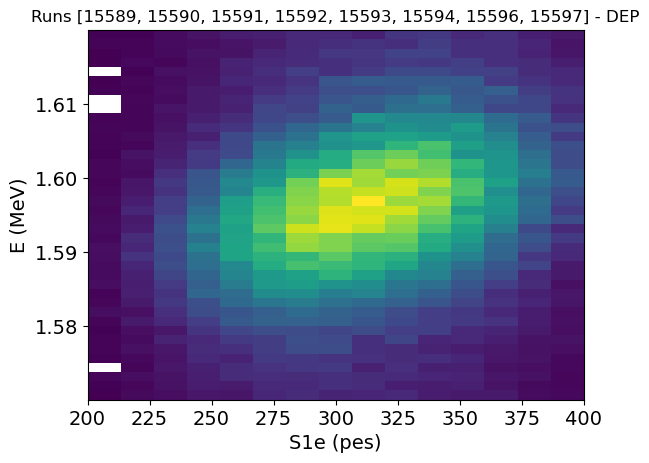

In [42]:
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], dep_range)], 'dZ', 'E_shifted', plotbins=(15, 20), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], dep_range)], 'Z_bary', 'E_shifted', plotbins=(30, 30), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], dep_range)], 'S1e', 'E_shifted', plotbins=(15, 40), plotrange=((200, 400), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)

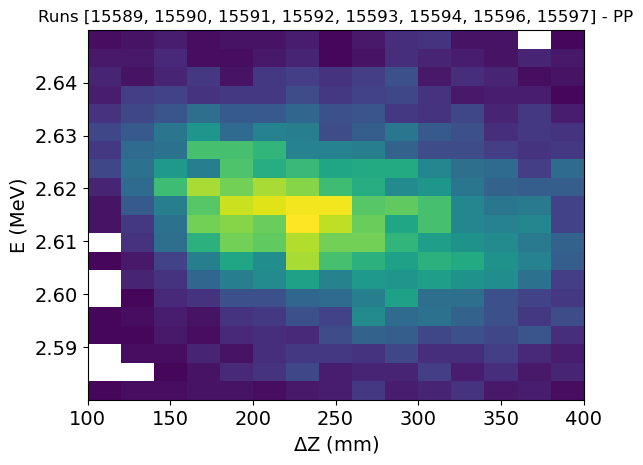

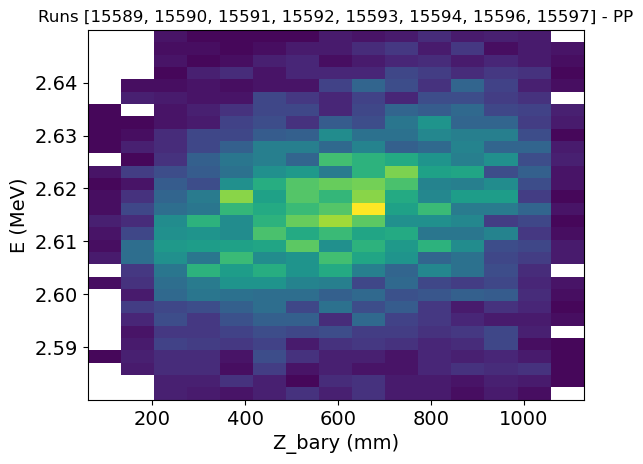

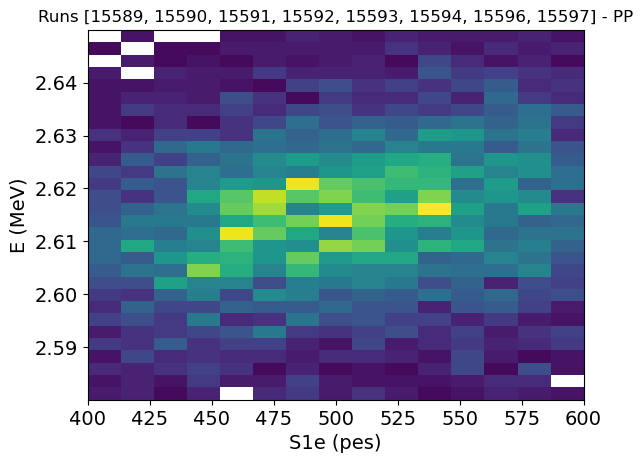

In [43]:
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], pp_range)], 'dZ', 'E_shifted', plotbins=(15, 20), plotrange=((100, 400), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], pp_range)], 'Z_bary', 'E_shifted', plotbins=(15, 30), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(reco_summ[in_range(reco_summ['E_shifted'], pp_range)], 'S1e', 'E_shifted', plotbins=(15, 30), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)

We see that:
* **$\Delta$ Z** was solved for DEP after the dropping out hits energy correction, but not for PP
* **Z_bary** is still an issue for now
* **S1e** gets mainly solved after correcting **Z_bary**, so we will not correct by it


## Energy dependencies correction

Following [JHEP 2019:230 (2019)](https://arxiv.org/abs/1905.13110), we will do a profile on the desired variable, and perform a linear fit:

$$E = x_0 + x * x_1$$

To correct the energy, we do:

$$E_{corr} = \frac{E_0}{1 + \frac{x_1}{x_0} * x}$$

### $\Delta$ Z

As I said before, I will correct just the PP by $\Delta$ Z

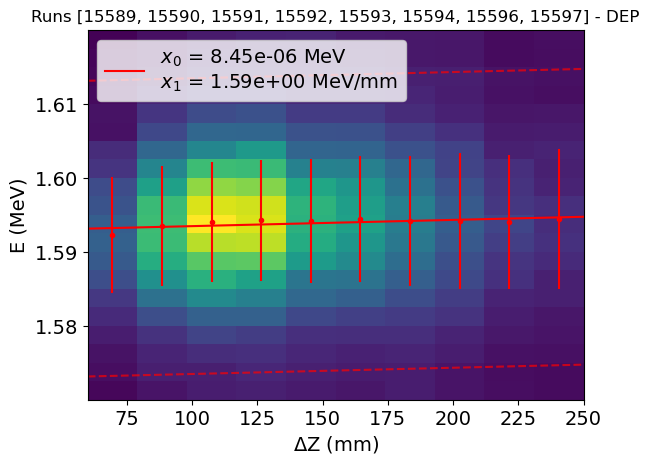

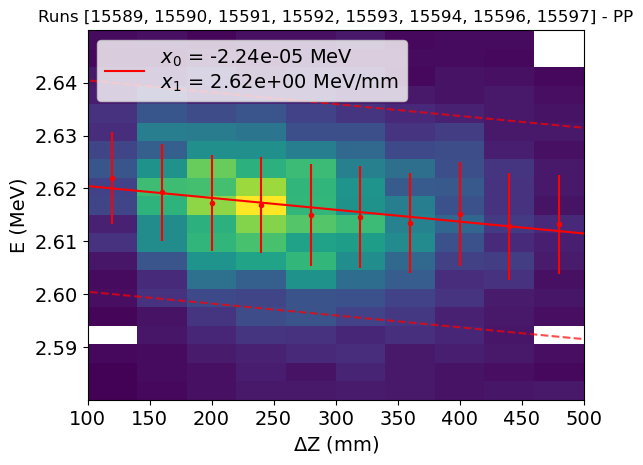

In [91]:
par_DEP_dZ = plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], dep_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((60, 250), None), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap, band_width = 0.02)
par_PP_dZ = plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((100, 500), None), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap, band_width = 0.02)

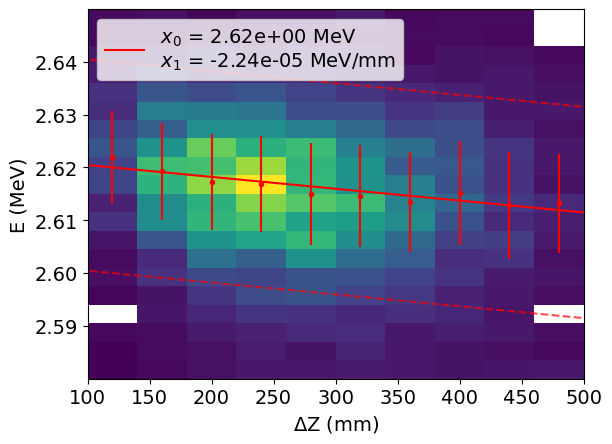

In [ ]:
plot_profile(reco_summ[in_range(reco_summ[ene_var_corr], pp_range)], 'dZ', ene_var_corr, fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((100, 500), None), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], cmap=cmap, band_width = 0.02, save = True)
# plt.savefig('/home/usc/ie/mpm/HE_plots/PP_dz_effect.pdf', dpi=600, bbox_inches='tight', transparent = True) 

In [92]:
dp_correct = reco_summ[in_range(reco_summ[ene_var_corr], dep_range)].copy()
pp_correct = reco_summ[in_range(reco_summ[ene_var_corr], pp_range)].copy()

# NO CORRECT IN DZ FOR DEP
dp_correct['E_dZ'] =  dp_correct[ene_var_corr] #/ (1 + (par_DEP_dZ[0][0] / par_DEP_dZ[0][1]) * dp_correct.dZ)
pp_correct['E_dZ'] =  pp_correct[ene_var_corr] / (1 + (par_PP_dZ[0][0] / par_PP_dZ[0][1]) * pp_correct.dZ)

Let's check how the other dependencies would have changed (just for PP)

The corrected variable:


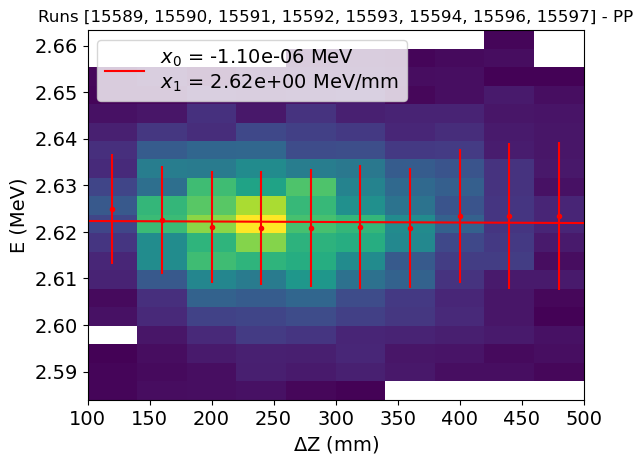

The other variables:


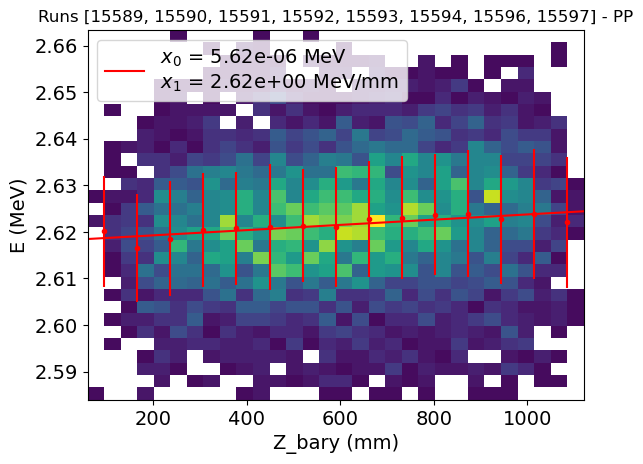

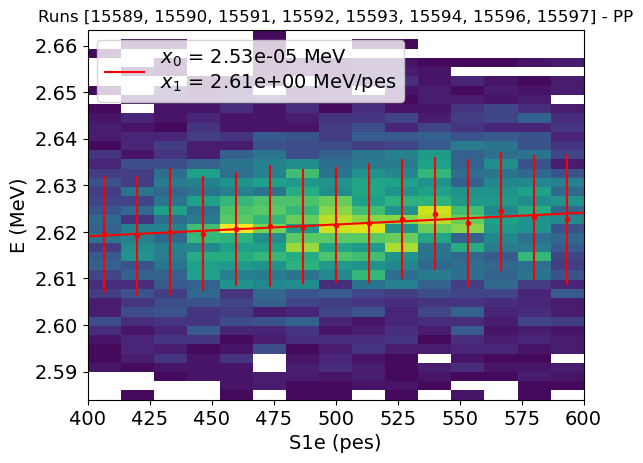

(array([2.52841185e-05, 2.60893386e+00]),
 array([3.28669723e-06, 1.64736841e-03]))

In [93]:
print('The corrected variable:')
plot_profile(pp_correct, 'dZ', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=10, plotbins=(10, 20), fitrange=((100, 500), None), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
print('The other variables:')
plot_profile(pp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_profile(pp_correct, 'S1e', 'E_dZ', fitfun=lineal, initial_values=(1.67, 0), std = True, fitbins=15, plotbins=(15, 40), fitrange=((400, 600), None), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)

And now the resulting resolution:

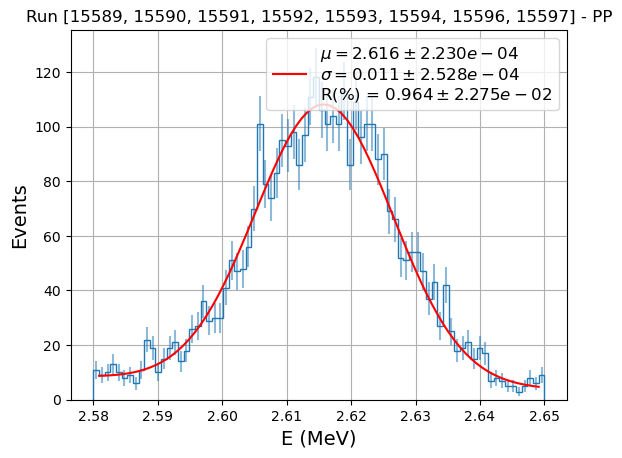

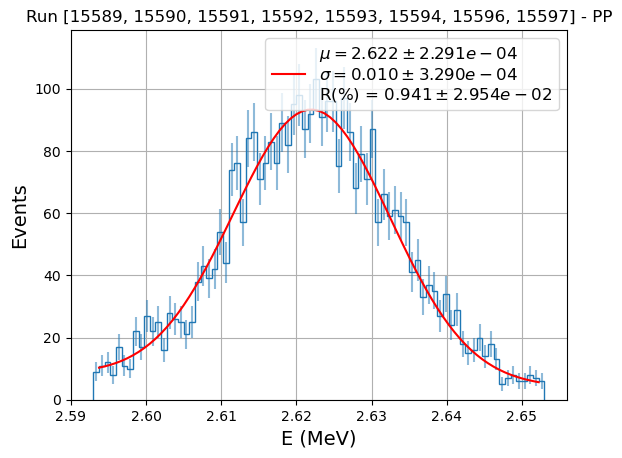

Energy resolution PP: 0.964 ± 0.023 %
Energy resolution PP (dZ corr): 0.941 ± 0.030 %


In [51]:
_, r_pp = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_dZ = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_dZ', peak_fit, (2.593, 2.653), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True) #(2.59, 2.65) for no band in profile
plt.show()


print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))
print('Energy resolution PP (dZ corr): {:.3f} ± {:.3f} %'.format(r_pp_dZ[0], r_pp_dZ[1]))

### Z_bary

Now we correct in the Z barycenter for both peaks

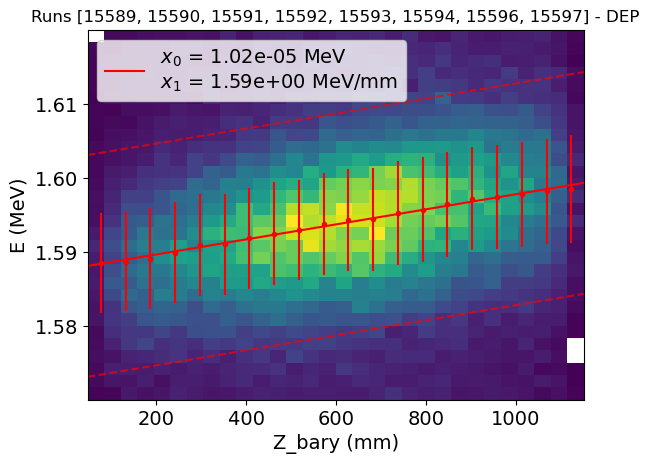

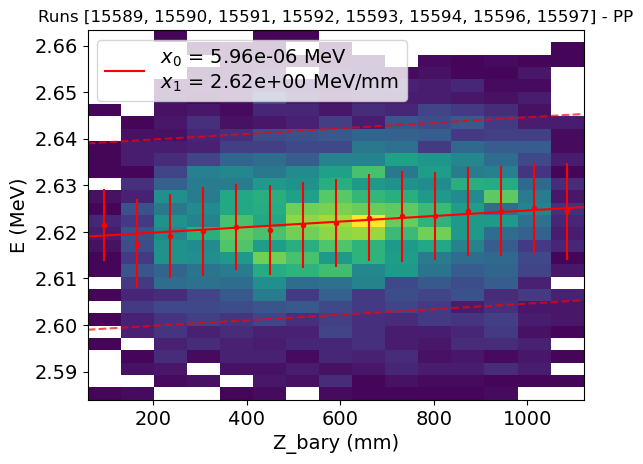

In [94]:
par_DEP_Z = plot_profile(dp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=20, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap, band_width=0.015)
par_PP_Z = plot_profile(pp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap, band_width = 0.02)


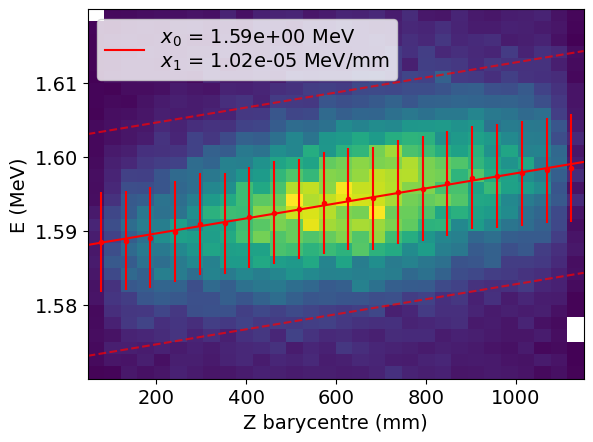

In [105]:
plot_profile(dp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=20, plotbins=(30, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z barycentre', 'E'], cmap=cmap, band_width=0.015, save = True)
plt.savefig('/home/usc/ie/mpm/HE_plots/DEP_z_effect.pdf', dpi=600, bbox_inches='tight', transparent = True) 

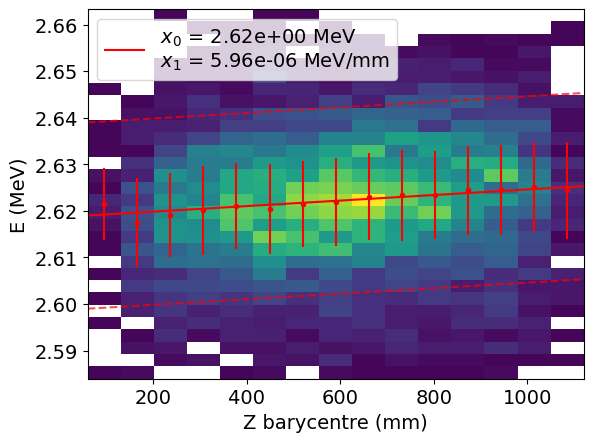

In [106]:
plot_profile(pp_correct, 'Z_bary', 'E_dZ', fitfun=lineal, initial_values=(0, 1.67), std = True, fitbins=15, plotbins=(15, 30), fitrange=(None, None), plotrange=(None, None), axlabel = ['Z barycentre', 'E'], cmap=cmap, band_width = 0.02, save = True)
plt.savefig('/home/usc/ie/mpm/HE_plots/PP_z_effect.pdf', dpi=600, bbox_inches='tight', transparent = True) 

In [97]:
dp_correct['E_Z'] =  dp_correct['E_dZ'] / (1 + (par_DEP_Z[0][0] / par_DEP_Z[0][1]) * dp_correct.Z_bary)
pp_correct['E_Z'] =  pp_correct['E_dZ'] / (1 + (par_PP_Z[0][0] / par_PP_Z[0][1]) * pp_correct.Z_bary)

Now check other dependencies:

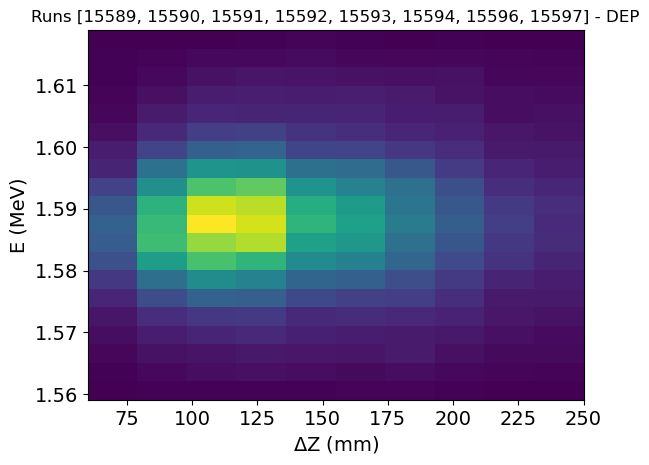

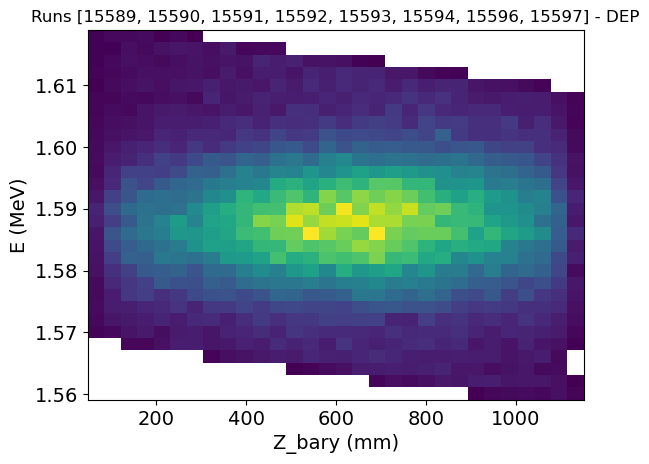

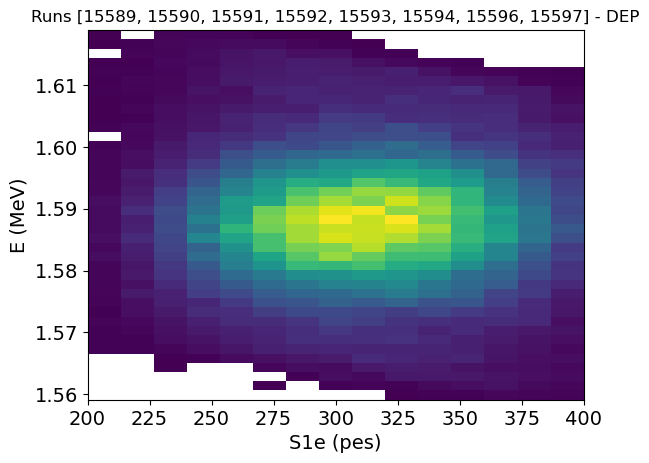

In [54]:
plot_hist2d(dp_correct, 'dZ', 'E_Z', plotbins=(10, 20), plotrange=((60, 250), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(dp_correct, 'Z_bary', 'E_Z', plotbins=(30, 30), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)
plot_hist2d(dp_correct, 'S1e', 'E_Z', plotbins=(15, 40), plotrange=((200, 400), None), axlabel = ['S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - DEP'.format(run_numbers), cmap=cmap)


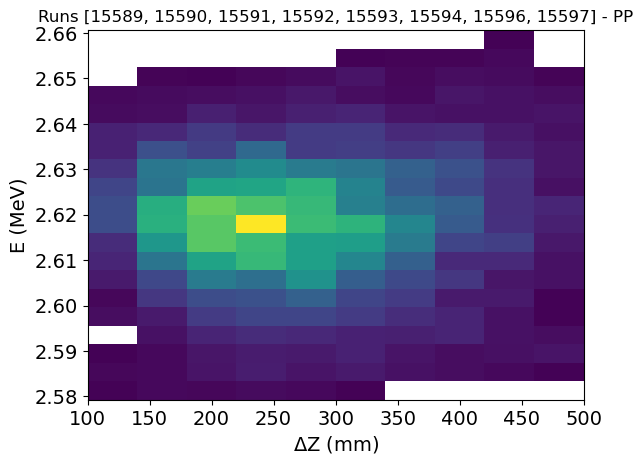

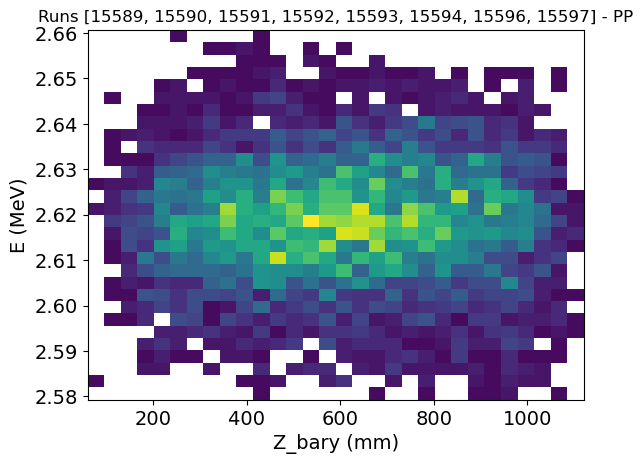

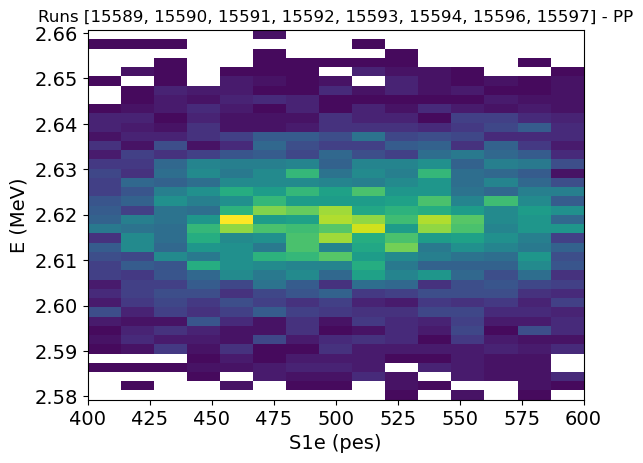

In [55]:
plot_hist2d(pp_correct, 'dZ', 'E_Z', plotbins=(10, 20), plotrange=((100, 500), None), axlabel = [r'$\Delta$Z', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(pp_correct, 'Z_bary', 'E_Z', plotbins=(30, 30), plotrange=(None, None), axlabel = [r'Z_bary', 'E'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)
plot_hist2d(pp_correct, 'S1e', 'E_Z', plotbins=(15, 40), plotrange=((400, 600), None), axlabel = [r'S1e', 'E'], units = ['pes', 'MeV'], title='Runs {} - PP'.format(run_numbers), cmap=cmap)


Most of them are gone now!

And how the resolution has improved for both:

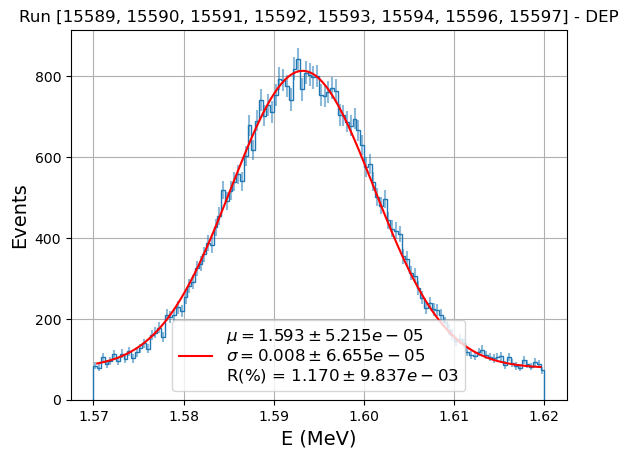

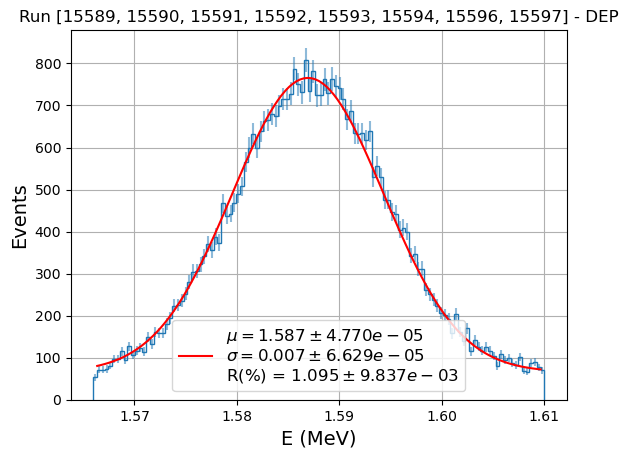

Energy resolution DEP: 1.170 ± 0.010 %
Energy resolution DEP (Z corr): 1.095 ± 0.010 %


In [76]:
_, r_dep = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, dep_range, 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True)
plt.show()
_, r_dep_Z = fit_whole_peaks(dp_correct[dp_correct.Rmax < 400], 'E_Z', peak_fit, (1.566, 1.61), 120, title = 'Run {} - '.format(run_numbers) + 'DEP', plot = True) # (1.567, 1.612) no band
plt.show()

print('Energy resolution DEP: {:.3f} ± {:.3f} %'.format(r_dep[0], r_dep[1]))
print('Energy resolution DEP (Z corr): {:.3f} ± {:.3f} %'.format(r_dep_Z[0], r_dep_Z[1]))

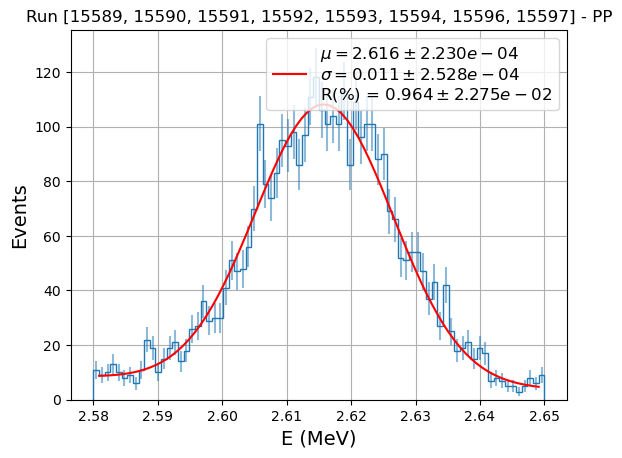

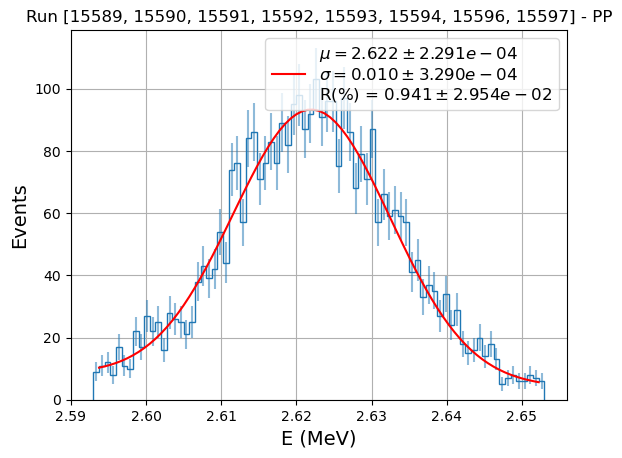

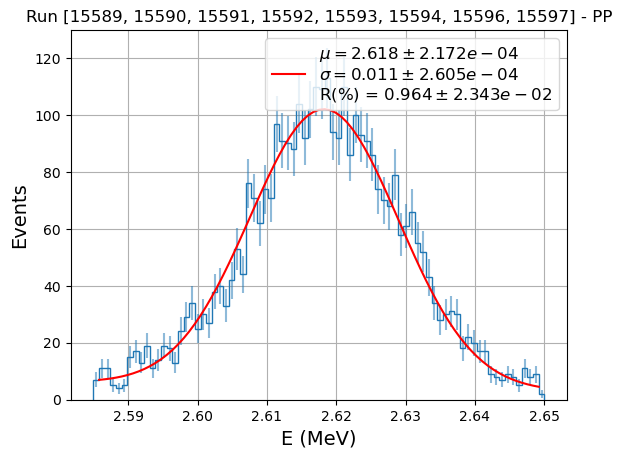

Energy resolution PP: 0.964 ± 0.023 %
Energy resolution PP (dZ corr): 0.941 ± 0.030 %
Energy resolution PP (dZ + Z corr): 0.964 ± 0.023 %


In [81]:
_, r_pp = fit_whole_peaks(reco_summ[reco_summ.Rmax < 400], ene_var_corr, peak_fit, pp_range, 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True)
plt.show()
_, r_pp_dZ = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_dZ', peak_fit, (2.593, 2.653), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True) #(2.59, 2.65) no band
plt.show()
_, r_pp_Z = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_Z', peak_fit, (2.585, 2.65), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True) #(2.59, 2.65) no band
plt.show()


print('Energy resolution PP: {:.3f} ± {:.3f} %'.format(r_pp[0], r_pp[1]))
print('Energy resolution PP (dZ corr): {:.3f} ± {:.3f} %'.format(r_pp_dZ[0], r_pp_dZ[1]))
print('Energy resolution PP (dZ + Z corr): {:.3f} ± {:.3f} %'.format(r_pp_Z[0], r_pp_Z[1]))

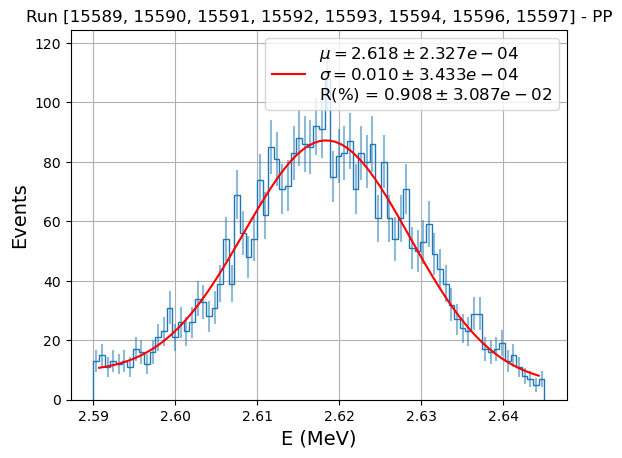

In [87]:
_, r_pp_Z = fit_whole_peaks(pp_correct[pp_correct.Rmax < 400], 'E_Z', peak_fit, (2.59, 2.645), 80, title = 'Run {} - '.format(run_numbers) + 'PP', plot = True) #(2.59, 2.65) no band
